# Question 2
## Libraries

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(530)

## Part A

In [5]:
def calculateTheResult(p, winner, loser):
    return (p ** winner) * ((1 - p) ** loser)

def bayesRule(p, ones, zeros):
    winner =  max(ones, zeros)
    loser = min(ones, zeros)
    winProbability = calculateTheResult(p, winner, loser)
    loseProbability = calculateTheResult(p, loser, winner)
    output = (0.5 * winProbability) / (0.5 * winProbability + 0.5 * loseProbability)
    return output
#A
scenarios = [
    {"Number": 1, "votes_0": 4, "votes_1": 8, "p": 0.7},
    {"Number": 2, "votes_0": 2, "votes_1": 10, "p": 0.7},
    {"Number": 3, "votes_0": 4, "votes_1": 8, "p": 0.3},
    {"Number": 4, "votes_0": 3, "votes_1": 9, "p": 0.5},
    {"Number": 5, "votes_0": 7, "votes_1": 5, "p": 0.5},
]
for scenario in scenarios:
    prob = bayesRule(scenario['p'], scenario['votes_1'], scenario['votes_0'])
    print("Scenario %i: Voting Accuracy = %.4f" %(scenario['Number'], prob))

Scenario 1: Voting Accuracy = 0.9674
Scenario 2: Voting Accuracy = 0.9989
Scenario 3: Voting Accuracy = 0.0326
Scenario 4: Voting Accuracy = 0.5000
Scenario 5: Voting Accuracy = 0.5000


## Part B

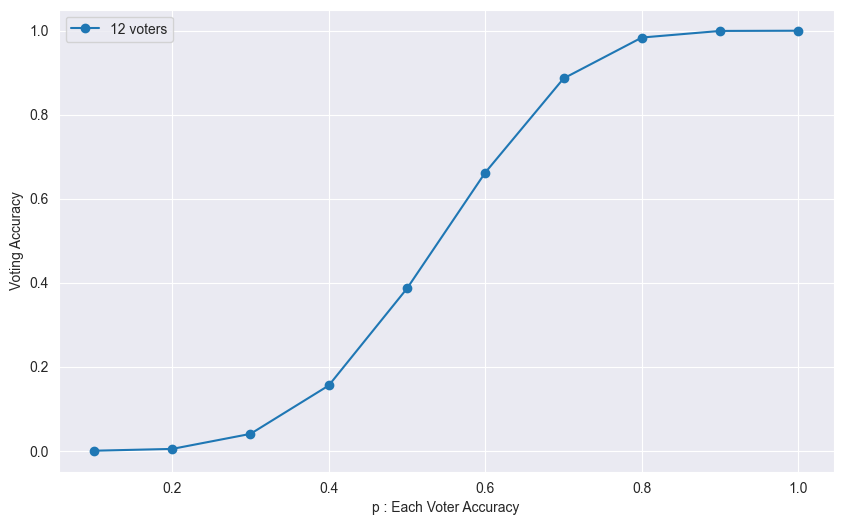

In [15]:
def simulateVoting(numOfVoters, p):
    correct = 0
    for i in range(10000):
        votes = []
        for j in range(numOfVoters):
            if np.random.rand() < p:
                votes.append(1)
            else:
                votes.append(0)
        votesResult = result(votes)
        if votesResult == 1:
            correct += 1
    return correct / 10000
def result(votes):
    return 1 if sum(votes) > len(votes) / 2 else 0
def plot(numOfVoters):
    accuracies = []
    pValues = np.arange(0.1, 1.1, 0.1)
    for p in pValues:
        accuracies.append(simulateVoting(numOfVoters, p))

    plt.figure(figsize=(10, 6))
    plt.plot(pValues, accuracies, label='%d voters' %numOfVoters, marker='o')
    plt.xlabel('p : Each Voter Accuracy')
    plt.ylabel('Voting Accuracy')
    plt.grid(True)
    plt.legend()
    plt.show()

plot(12)

## Part C


In [19]:
def findOptimal(numOfVoters):
    p_values = np.arange(0.5, 1.01, 0.01)
    for p in p_values:
        accuracy = simulateVoting(numOfVoters, p)
        if accuracy == 1.0:
            return p
    return None
print("Optimal Accuracy is = %.4f" %findOptimal(12))

Optimal Accuracy is = 0.9300


# Part D

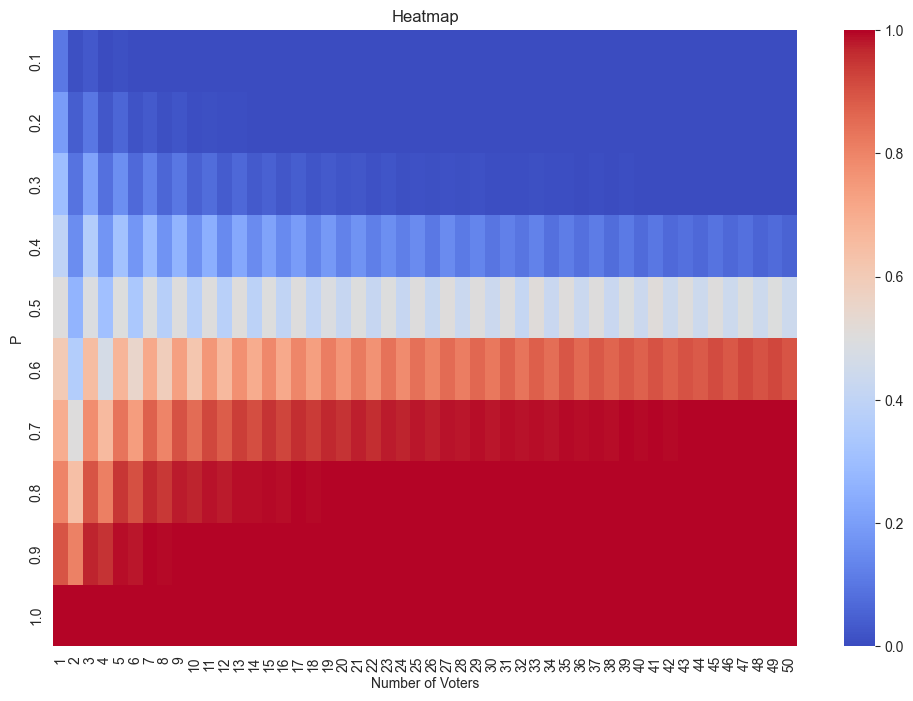

In [21]:
def plot_heatmap():
    pValues = np.arange(0.1, 1.1, 0.1)
    nValues = np.arange(1, 51)
    heatmap_data = np.zeros((len(pValues), len(nValues)))

    for i, p in enumerate(pValues):
        for j, n in enumerate(nValues):
            heatmap_data[i, j] = simulateVoting(n, p)

    plt.figure(figsize=(12, 8))
    sns.heatmap(heatmap_data, xticklabels=nValues, yticklabels=np.round(pValues, 2), cmap="coolwarm")
    plt.xlabel('Number of Voters')
    plt.ylabel('P')
    plt.title('Heatmap')
    plt.show()


plot_heatmap()